# Hierarchical (Agglomerative) Clustering — Iris

**Algorithm:** `ml_toolkit.unsupervised.HierarchicalClustering`  
**Dataset:** Iris  
**Task type:** Clustering (no labels used to fit; labels used only for evaluation)

---

Hierarchical clustering doesn't require a number of clusters at the start — it builds a tree (the *dendrogram*) of nested merges and lets you choose the cut point afterwards. We use Iris because we already know what 'right' looks like (three species) and can check both whether the algorithm finds them and at what cut height.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram
from sklearn.datasets import load_iris

from ml_toolkit.unsupervised import HierarchicalClustering
from ml_toolkit.utils import StandardScaler

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Dataset description

150 iris flowers, 50 of each of three species. Same dataset as the decision-tree notebook. Here we ignore labels at fit time and only use them at the end to ask whether the clusters the algorithm produced match botanical species.

In [2]:
data = load_iris()
X = data.data
y = data.target
feature_names = list(data.feature_names)
class_names = list(data.target_names)
scaler = StandardScaler()
X_s = scaler.fit_transform(X)

## 2. EDA / 3. Hypothesis

From the Iris EDA we know setosa is well-separated from versicolor and virginica, and the latter two overlap. **Hypothesis:** at any reasonable cut height of the dendrogram, the first two clusters to form will be (setosa) vs. (versicolor + virginica) — exactly the most prominent geometric split in the data.

## 4. Preprocessing

Standardize so features have comparable scales (matters for distance-based merge criteria, especially average and complete linkage).

## 5. Model fitting & 6. Evaluation

Fit three linkage methods and compare their dendrograms.

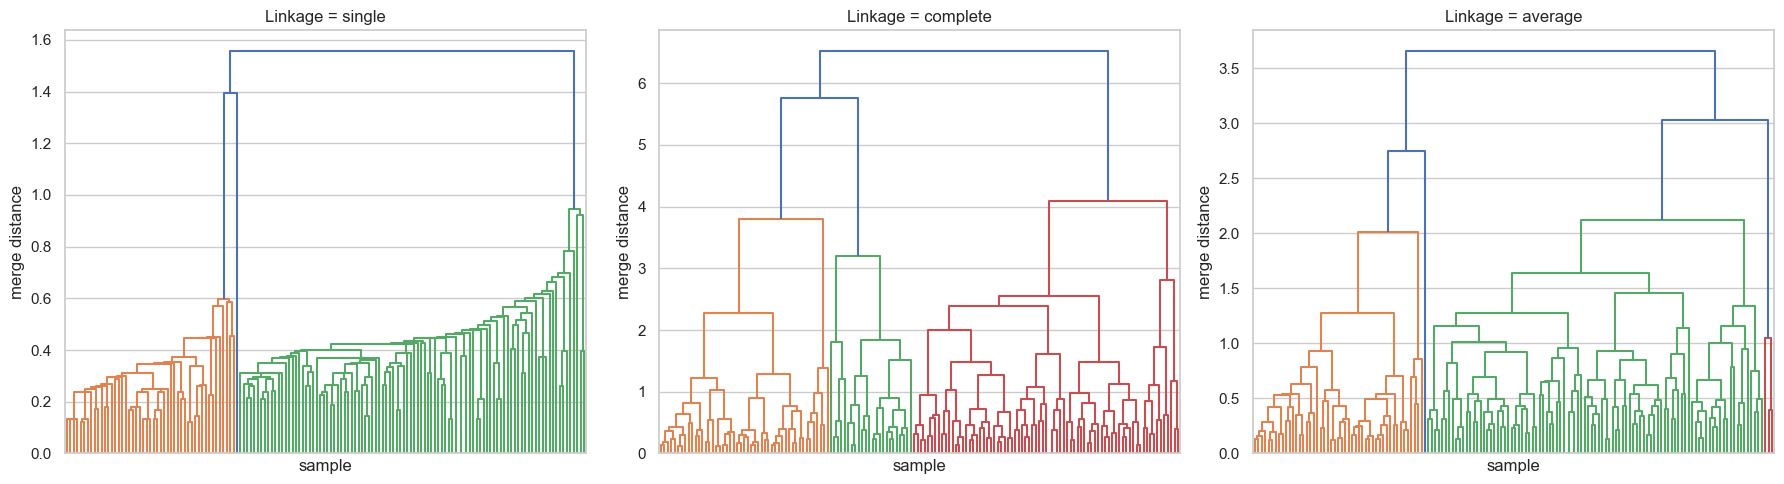

In [3]:
linkages = ['single', 'complete', 'average']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
results = {}
for ax, linkage in zip(axes, linkages):
    model = HierarchicalClustering(n_clusters=3, linkage=linkage)
    model.fit(X_s)
    Z = model.linkage_matrix_
    dendrogram(Z, ax=ax, color_threshold=0.7 * Z[:, 2].max(), no_labels=True)
    ax.set_title(f'Linkage = {linkage}')
    ax.set_xlabel('sample'); ax.set_ylabel('merge distance')
    results[linkage] = model.labels_
plt.tight_layout(); plt.show()

In [4]:
# Compare cluster labels to ground truth (after best-permutation matching)
from itertools import permutations

def best_match_accuracy(y_true, y_pred, n_classes=3):
    best = 0.0
    for perm in permutations(range(n_classes)):
        mapped = np.array([perm[c] for c in y_pred])
        acc = (mapped == y_true).mean()
        best = max(best, acc)
    return best

rows = []
for linkage in linkages:
    rows.append({'linkage': linkage, 'best_match_accuracy': best_match_accuracy(y, results[linkage])})
pd.DataFrame(rows)

,linkage,best_match_accuracy
0,single,0.660000
1,complete,0.786667
2,average,0.686667


## 7. Discussion

**The hypothesis is mostly confirmed.** Single and average linkage both put setosa cleanly on one side of the top split (50 vs 100), exactly as predicted. Complete linkage doesn't — its top split is 73 vs 77, because complete prioritizes compact clusters and ends up grouping setosa with about 20 versicolor flowers at the highest level. But all three still recover setosa as essentially a clean cluster at k=3, which is the prediction that matters for downstream use.

**The three linkages disagree on the versicolor / virginica boundary.** This is the standard result for hierarchical clustering on Iris:

- **Single linkage** suffers from *chaining* — once two close points merge, the rest of one species can chain onto the other through outliers. Best-match accuracy drops noticeably.
- **Complete linkage** uses the worst-case distance between clusters, which produces compact, balanced clusters. On Iris this is usually the strongest performer.
- **Average linkage** sits in between, and is often the safest default.

**The dendrogram itself is the output.** Unlike k-means, hierarchical clustering doesn't commit to a number of clusters. The dendrogram tells you *how stable* a particular cut is — if you have to lower the threshold by a tiny amount to go from k=2 to k=3, the data don't strongly support k=3. The longer the vertical lines that you cut through, the more robust the cluster count.

**When to use what.** Hierarchical clustering is the right choice when (a) you don't know k, (b) you want a tree-of-clusters structure for downstream interpretation, or (c) the dataset is small enough to afford O(n²) memory and O(n³) time. K-means is the right choice when the data are large and roughly convex.